In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import integrate
from numpy.polynomial.legendre import leggauss

## Zadanie 1 – Zlożone kwadratury prostokątów, trapezów i Simpsona

Calka: $\int_0^1 \frac{4}{1+x^2}\,dx = \pi$

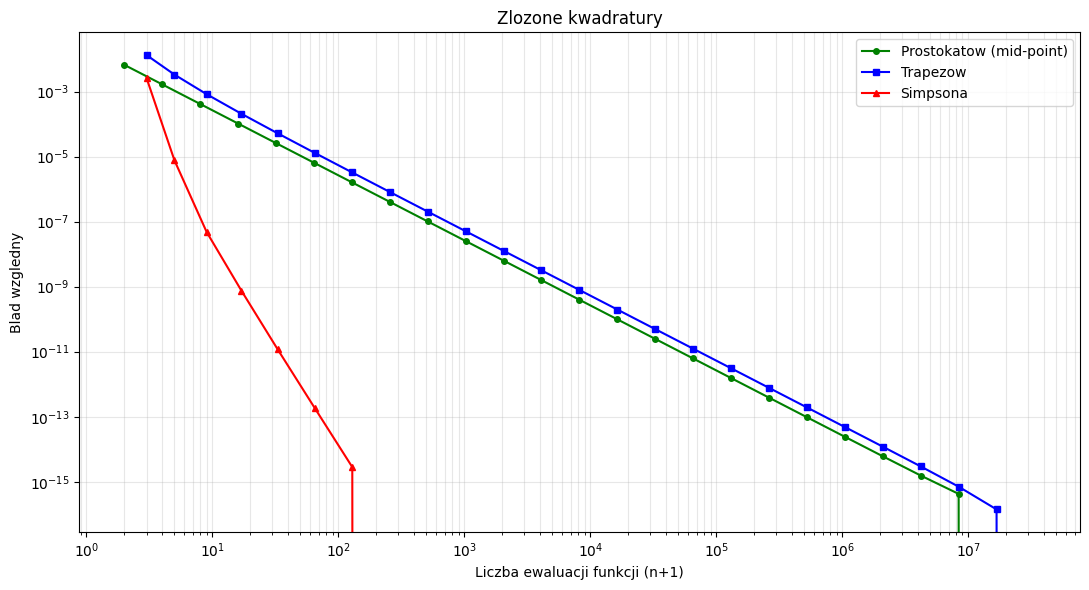

In [2]:
def f(x):
    x = np.float64(x)
    return np.float64(4.0) / (np.float64(1.0) + x**2)

TRUE_VAL = np.float64(np.pi)

def rel_err(approx):
    return np.float64(abs(approx - TRUE_VAL) / TRUE_VAL)

ms = np.arange(1, 26)

n_evals_trap = []
n_evals_simp = []
n_evals_mid  = []

err_trap = []
err_simp = []
err_mid  = []

for m in ms:
    n = 2**m
    x = np.linspace(0, 1, n + 1, dtype=np.float64)
    y = f(x)
    h = np.float64(x[1] - x[0])

    I_trap = np.float64(integrate.trapezoid(y, x))
    err_trap.append(rel_err(I_trap))
    n_evals_trap.append(n + 1)

    I_simp = np.float64(integrate.simpson(y, x=x))
    err_simp.append(rel_err(I_simp))
    n_evals_simp.append(n + 1)

    x_mid = (x[:-1] + x[1:]) / np.float64(2.0)
    I_mid = h * np.sum(f(x_mid))
    err_mid.append(rel_err(I_mid))
    n_evals_mid.append(n)

fig, ax = plt.subplots(figsize=(11, 6))
ax.loglog(n_evals_mid,  err_mid,  'g-o', markersize=4, label='Prostokatow (mid-point)')
ax.loglog(n_evals_trap, err_trap, 'b-s', markersize=4, label='Trapezow')
ax.loglog(n_evals_simp, err_simp, 'r-^', markersize=4, label='Simpsona')
ax.set_xlabel('Liczba ewaluacji funkcji (n+1)')
ax.set_ylabel('Blad wzgledny')
ax.set_title('Zlozone kwadratury')
ax.legend()
ax.grid(True, which='both', alpha=0.3)
plt.tight_layout()
plt.show()

### (b) Minimalne h i granica bledu numerycznego

In [3]:
err_trap_arr = np.array(err_trap, dtype=np.float64)
n_trap_arr   = np.array(n_evals_trap, dtype=np.float64)

idx_min = np.argmin(err_trap_arr)
n_min   = n_trap_arr[idx_min]
h_min   = np.float64(1.0) / (n_min - np.float64(1.0))
eps_mach = np.finfo(np.float64).eps

print(f"Metoda trapezow:")
print(f"  Minimalna liczba ewaluacji: n+1 = {n_min}")
print(f"  Odpowiadajace h_min = {h_min:.2e}")
print(f"  Minimalny blad wzgledny = {err_trap_arr[idx_min]:.2e}")
print()
print(f"Epsilon maszynowy (float64): eps = {eps_mach:.2e}")
print(f"Teoria dla trapezow: h_min ~ eps^(1/3) = {eps_mach**(1/3):.2e}")
print(f"Teoria dla Simpsona: h_min ~ eps^(1/5) = {eps_mach**(1/5):.2e}")
print()
print("Ponizej h_min blad zaokraglenia (numeryczny) dominuje nad bledem metody (obciecia).")
print("Wynika to z ograniczonej precyzji arytmetyki float64 (~15-16 cyfr znaczacych).")

Metoda trapezow:
  Minimalna liczba ewaluacji: n+1 = 33554433.0
  Odpowiadajace h_min = 2.98e-08
  Minimalny blad wzgledny = 0.00e+00

Epsilon maszynowy (float64): eps = 2.22e-16
Teoria dla trapezow: h_min ~ eps^(1/3) = 6.06e-06
Teoria dla Simpsona: h_min ~ eps^(1/5) = 7.40e-04

Ponizej h_min blad zaokraglenia (numeryczny) dominuje nad bledem metody (obciecia).
Wynika to z ograniczonej precyzji arytmetyki float64 (~15-16 cyfr znaczacych).


### (c) Empiryczny rzad zbieznosci

In [4]:
def empirical_order(n_evals, errors, cut):
    n = np.array(n_evals[:cut], dtype=np.float64)
    e = np.array(errors[:cut], dtype=np.float64)
    h = np.float64(1.0) / (n - np.float64(1.0))
    mask = (e > np.float64(1e-15))
    coeffs = np.polyfit(np.log(h[mask]), np.log(e[mask]), 1)
    return coeffs[0]

cut = 15

order_mid  = empirical_order(n_evals_mid,  err_mid,  cut)
order_trap = empirical_order(n_evals_trap, err_trap, cut)
order_simp = empirical_order(n_evals_simp, err_simp, cut)

print(f"{'Metoda':<25} {'Rzad empiryczny':>18} {'Rzad teoret.':>15}")
print("-" * 60)
print(f"{'Prostokatow (mid-point)':<25} {order_mid:>18.2f} {'2':>15}")
print(f"{'Trapezow':<25} {order_trap:>18.2f} {'2':>15}")
print(f"{'Simpsona':<25} {order_simp:>18.2f} {'4':>15}")
print()
print("Rzad zbieznosci p oznacza: blad ~ h^p")
print("Prostokatow i trapezow: O(h^2), Simpsona: O(h^4)")

Metoda                       Rzad empiryczny    Rzad teoret.
------------------------------------------------------------
Prostokatow (mid-point)                 1.92               2
Trapezow                                2.00               2
Simpsona                                6.50               4

Rzad zbieznosci p oznacza: blad ~ h^p
Prostokatow i trapezow: O(h^2), Simpsona: O(h^4)


## Zadanie 2 – Kwadratura Gaussa-Legendre'a

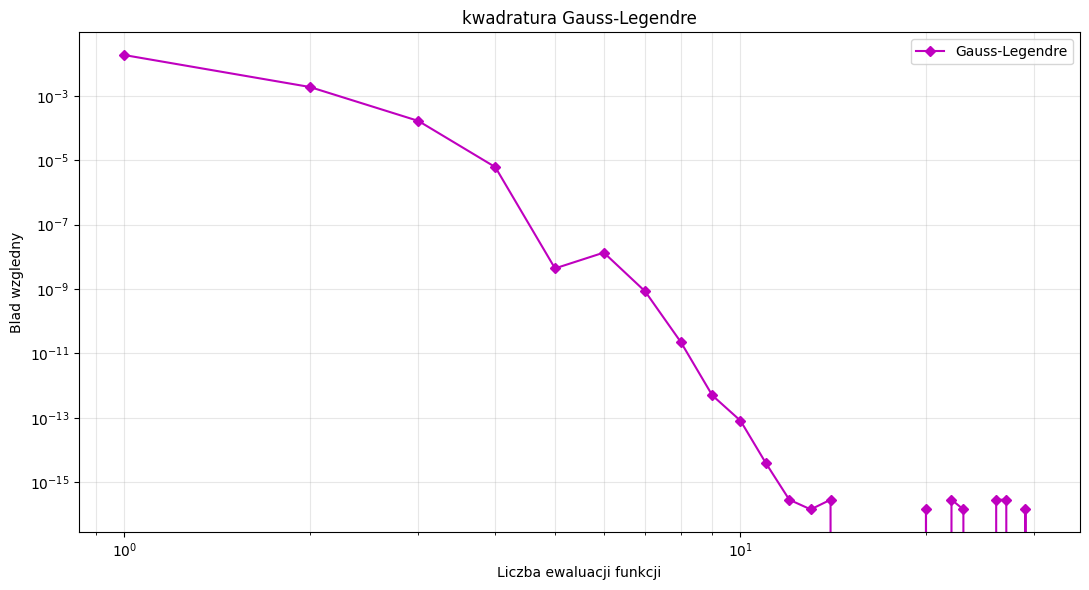

Gauss-Legendre: minimalny blad = 0.00e+00 przy n = 15
GL zbiega spektralnie (eksponencjalnie) – kilkanascie wezlow wystarczy.


In [10]:
n_gl_list = list(range(1, 31))
n_evals_gl = []
err_gl = []

for n in n_gl_list:
    xi, wi = leggauss(n)
    xi = np.float64(xi)
    wi = np.float64(wi)
    x_mapped = np.float64(0.5) * (xi + np.float64(1.0))
    w_mapped = wi
    I_gl = np.float64(0.5)*np.dot(w_mapped, f(x_mapped))
    e = rel_err(I_gl)
    err_gl.append(e)
    n_evals_gl.append(n)

fig, ax = plt.subplots(figsize=(11, 6))
ax.loglog(n_evals_gl,   err_gl,   'm-D', markersize=5, label='Gauss-Legendre')
ax.set_xlabel('Liczba ewaluacji funkcji')
ax.set_ylabel('Blad wzgledny')
ax.set_title('kwadratura Gauss-Legendre')
ax.legend()
ax.grid(True, which='both', alpha=0.3)
plt.tight_layout()
plt.show()

best_idx = int(np.argmin(err_gl))
print(f"Gauss-Legendre: minimalny blad = {err_gl[best_idx]:.2e} przy n = {n_gl_list[best_idx]}")
print("GL zbiega spektralnie (eksponencjalnie) – kilkanascie wezlow wystarczy.")

## Zadanie 3 – Kwadratury adaptacyjne trapezow i Gaussa-Kronroda

C:\Users\matis\AppData\Local\Temp\ipykernel_28720\126717288.py:2: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  x = np.float64(x)


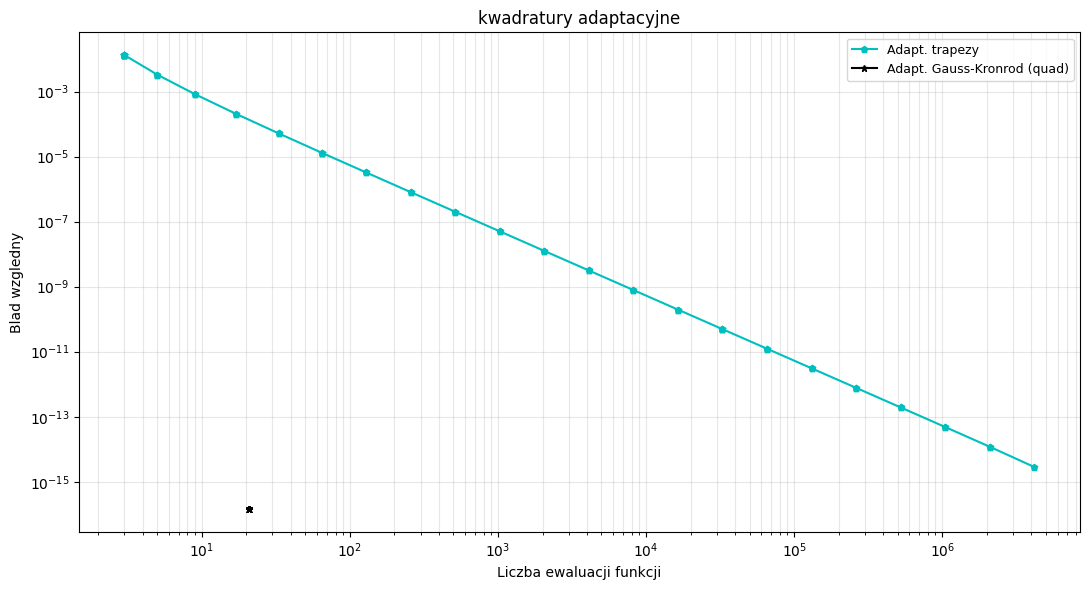

In [ ]:
def adaptive_trap(a, b, tol):
    a = np.float64(a)
    b = np.float64(b)
    tol = np.float64(tol)
    h = b - a
    I_old = h * (f(a) + f(b)) / np.float64(2.0)
    neval = 2
    n_intervals = 1
    for _ in range(55):
        n_intervals *= 2
        h /= np.float64(2.0)
        x_new = a + h * np.arange(1, n_intervals, 2, dtype=np.float64)
        I_new = I_old / np.float64(2.0) + h * np.sum(f(x_new))
        neval += len(x_new)
        if neval > 2 and abs(I_new - I_old) < np.float64(3.0) * tol * abs(I_new):
            return I_new, neval
        I_old = I_new
    return I_new, neval


tolerances = np.logspace(0, -14, 50, dtype=np.float64)

n_evals_adapt_trap = []
err_adapt_trap = []
n_evals_gk = []
err_gk = []

for tol in tolerances:
    val, nev = adaptive_trap(0.0, 1.0, tol)
    err_adapt_trap.append(rel_err(val))
    n_evals_adapt_trap.append(nev)

    quad_out = integrate.quad(f, 0, 1, epsabs=tol, epsrel=tol, full_output=True)
    res_gk = np.float64(quad_out[0])
    info_gk = quad_out[2]
    err_gk.append(rel_err(res_gk))
    n_evals_gk.append(info_gk['neval'])

fig, ax = plt.subplots(figsize=(11, 6))
ax.loglog(n_evals_adapt_trap, err_adapt_trap, 'c-p', markersize=5, label='Adapt. trapezy')
ax.loglog(n_evals_gk,         err_gk,         'k-*', markersize=5, label='Adapt. Gauss-Kronrod (quad)')
ax.set_xlabel('Liczba ewaluacji funkcji')
ax.set_ylabel('Blad wzgledny')
ax.set_title('kwadratury adaptacyjne')
ax.legend(fontsize=9)
ax.grid(True, which='both', alpha=0.3)
plt.tight_layout()
plt.show()

## Zadanie 4 – Monte-Carlo

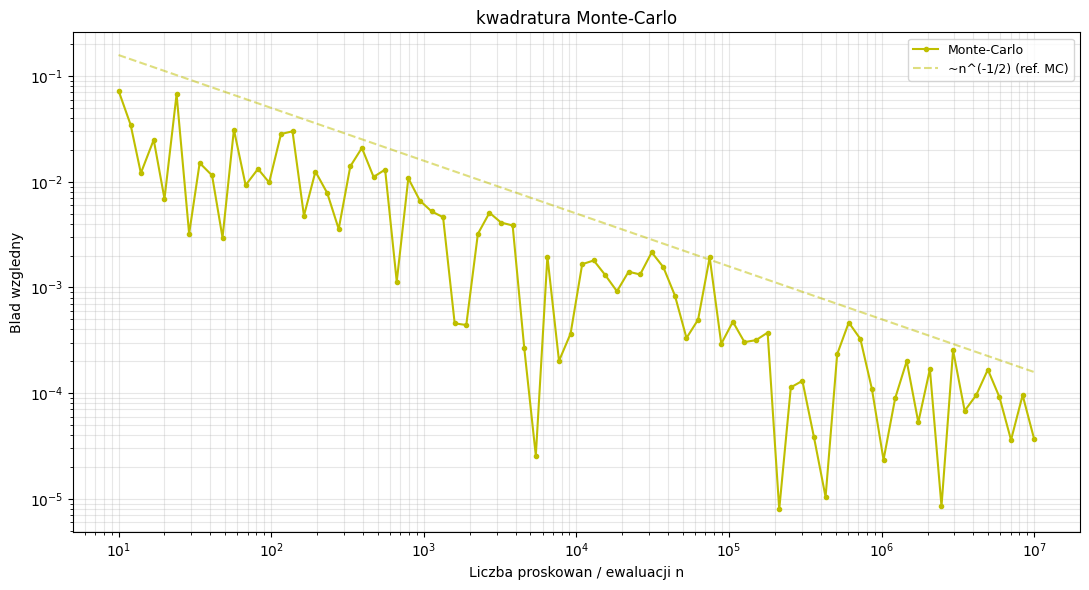

In [ ]:
rng = np.random.default_rng(42)

ns_mc = np.unique(np.round(np.logspace(1, 7, 80)).astype(int))
err_mc = []

for n in ns_mc:
    x_rand = rng.uniform(0.0, 1.0, n).astype(np.float64)
    I_mc = np.mean(f(x_rand), dtype=np.float64)
    err_mc.append(max(rel_err(I_mc), np.float64(1e-17)))

fig, ax = plt.subplots(figsize=(11, 6))
ax.loglog(ns_mc,              err_mc,         'y-o', markersize=3, label='Monte-Carlo')

n_ref = np.array([1e1, 1e7], dtype=np.float64)
ax.loglog(n_ref, np.float64(0.5) / np.sqrt(n_ref), 'y--', alpha=0.5, label='~n^(-1/2) (ref. MC)')

ax.set_xlabel('Liczba proskowan / ewaluacji n')
ax.set_ylabel('Blad wzgledny')
ax.set_title('kwadratura Monte-Carlo')
ax.legend(fontsize=9)
ax.grid(True, which='both', alpha=0.3)
plt.tight_layout()
plt.show()

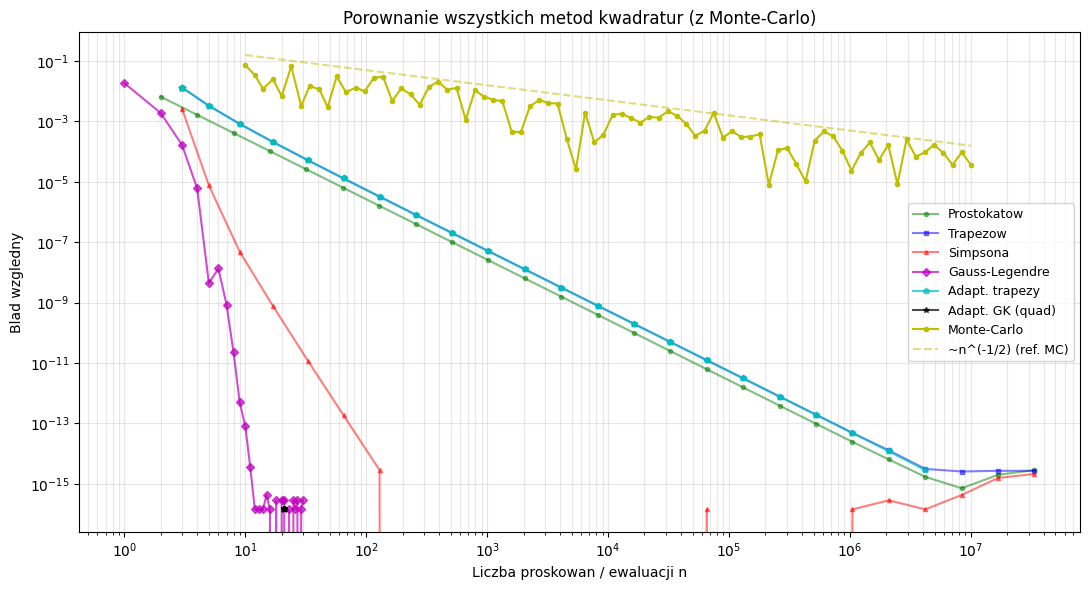

In [ ]:
fig, ax = plt.subplots(figsize=(11, 6))
ax.loglog(n_evals_mid,        err_mid,        'g-o', markersize=3, alpha=0.5, label='Prostokatow')
ax.loglog(n_evals_trap,       err_trap,       'b-s', markersize=3, alpha=0.5, label='Trapezow')
ax.loglog(n_evals_simp,       err_simp,       'r-^', markersize=3, alpha=0.5, label='Simpsona')
ax.loglog(n_evals_gl,         err_gl,         'm-D', markersize=4, alpha=0.7, label='Gauss-Legendre')
ax.loglog(n_evals_adapt_trap, err_adapt_trap, 'c-p', markersize=4, alpha=0.7, label='Adapt. trapezy')
ax.loglog(n_evals_gk,         err_gk,         'k-*', markersize=4, alpha=0.7, label='Adapt. GK (quad)')
ax.loglog(ns_mc,              err_mc,         'y-o', markersize=3, label='Monte-Carlo')

n_ref = np.array([1e1, 1e7], dtype=np.float64)
ax.loglog(n_ref, np.float64(0.5) / np.sqrt(n_ref), 'y--', alpha=0.5, label='~n^(-1/2) (ref. MC)')

ax.set_xlabel('Liczba proskowan / ewaluacji n')
ax.set_ylabel('Blad wzgledny')
ax.set_title('Porownanie wszystkich metod kwadratur (z Monte-Carlo)')
ax.legend(fontsize=9)
ax.grid(True, which='both', alpha=0.3)
plt.tight_layout()
plt.show()